In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import sys
import numpy as np
import pickle

sys.path.append('D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin')
from models import *
from clients_datasets import *
from tqdm.notebook import tqdm
from utils import *
from AttFunc import *
from Fisher_LeNet import *

In [3]:
batch_size = 600
epochs = 30
NC = 10
dataset = 'f_mnist'

clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
clients_testloader = load_clients_testsets(dataset, NC, batch_size)

server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
client_level = 1
server_level = 4

criterion = torch.nn.CrossEntropyLoss()

In [4]:
am = LeNet_5().cuda()
am_train(am, clients_trainloader[8], dataset)

att_type = 'unit'
acc0 = 89.45
betas = []

for i in range(10):
    beta = simulated_annealing(dataset, 1, 500, att_type, acc0,  clients_testloader[8])
    betas.append(beta)
    print(beta)

beta_mean, beta_range = data_process(betas)
print('------------------------------------')
print(beta_mean)

Training attack model:   0%|          | 0/100 [00:00<?, ?eopch/s]

0.16549286854441497
1.0210135552054562
0.183184173044991
0.14337107822186793
0.14420466135495894
0.7928805886187872
0.13053959454320818
0.19015748654122366
0.21521475521058153
1.4209024758267983


D:\Program\MyCode\Round_robin_SL_venv\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
D:\Program\MyCode\Round_robin_SL_venv\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: zero-size array to reduction operation minimum which has no identity

In [13]:
acc0 = 89.45
att_type = 'unit'
ID_acc1 = []
clients_acc1 = []
iters = 10
mode = 'Basic'

for iter in tqdm(range(iters), desc="Training", unit="iter"):
    # get ready
    batch_size = 600
    epochs = 30
    NC = 10
    dataset = 'f_mnist'
    clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
    clients_testloader = load_clients_testsets(dataset, NC, batch_size)
    server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
    client_level = 1
    server_level = 4
    criterion = torch.nn.CrossEntropyLoss()

    # train
    mal_client_id = iter
    server.train()
    for i in range(NC):
        clients[i].train()
    server.apply(init_weights)
    clients[0].apply(init_weights)
    last_trained_params = clients[0].state_dict()
    for epoch in range(epochs):
        beta = beta_mean
        for idx, client in enumerate(clients):
            client.load_state_dict(last_trained_params)
            for j, data in enumerate(clients_trainloader[idx]):
                # training part
                images, labels = data
                images = images.cuda()
                labels = labels.cuda()
                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                clients_opts[idx].zero_grad()
                server_opt.zero_grad()
                loss = criterion(output, labels)
                loss.backward()
                clients_opts[idx].step()
                server_opt.step()
            # weight sharing
            last_trained_params = client.state_dict()
            # attack part
            if idx == mal_client_id :
                benign_params = list(client.parameters())[:2]
                mal_params = perturbation(beta=beta, bp=benign_params, type=att_type)
                last_trained_params['conv1.0.weight'] = mal_params[0]
                last_trained_params['conv1.0.bias'] = mal_params[1]
    for i in range(NC):
        clients[i].load_state_dict(last_trained_params)

    # test
    server.eval()
    for i in range(NC):
        clients[i].eval()
    with torch.no_grad():
        for idx, client in enumerate(clients):
            correct = 0
            total = 0
            acc1 = 0
            for data in clients_testloader[idx]:
                images, labels = data
                images, labels = images.cuda(), labels.cuda()

                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                _, pre = torch.max(output.data, 1)
                total += images.shape[0]
                correct += (pre == labels).sum().item()
            acc1 = 100 * correct / total
            clients_acc1.append(acc1)
    acc1 = np.mean(clients_acc1)
    ID_acc1.append(acc1)

print(ID_acc1)
np.save(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy', ID_acc1)

Training:   0%|          | 0/10 [00:00<?, ?iter/s]

[83.71000000000001, 82.17, 81.38333333333335, 80.6475, 80.45400000000001, 80.885, 80.99285714285713, 80.835, 81.06222222222223, 80.536]


In [16]:
acc0 = 89.45
att_type = 'unit'
ID_acc1 = []
clients_acc1 = []
iters = 10
mode = 'Fisher'

for iter in tqdm(range(iters), desc="Training", unit="iter"):
    # get ready
    batch_size = 600
    epochs = 30
    NC = 10
    dataset = 'f_mnist'
    clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
    clients_testloader = load_clients_testsets(dataset, NC, batch_size)
    server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
    client_level = 1
    server_level = 4
    criterion = torch.nn.CrossEntropyLoss()

    # train
    mal_client_id = iter
    server.train()
    for i in range(NC):
        clients[i].train()
    server.apply(init_weights)
    clients[0].apply(init_weights)
    last_trained_params = clients[0].state_dict()
    for epoch in range(epochs):
        beta = beta_mean
        for idx, client in enumerate(clients):
            client.load_state_dict(last_trained_params)
            for j, data in enumerate(clients_trainloader[idx]):
                # training part
                images, labels = data
                images = images.cuda()
                labels = labels.cuda()
                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                clients_opts[idx].zero_grad()
                server_opt.zero_grad()
                loss = criterion(output, labels)
                loss.backward()
                clients_opts[idx].step()
                server_opt.step()
            # weight sharing
            last_trained_params = client.state_dict()
            # attack part
            if idx == mal_client_id :
                benign_params = list(client.parameters())[:2]
                fisher_matrix = {}
                for param_name, param in client.named_parameters():
                    if param_name == 'conv1.0.weight':
                        grad = param.grad.cpu().detach().numpy()
                        if param_name not in fisher_matrix:
                            fisher_matrix[param_name] = grad ** 2
                        else:
                            fisher_matrix[param_name] += grad ** 2
                    if param_name == 'conv1.0.bias':
                        grad = param.grad.cpu().detach().numpy()
                        if param_name not in fisher_matrix:
                            fisher_matrix[param_name] = grad ** 2
                        else:
                            fisher_matrix[param_name] += grad ** 2
                weight_positions = []
                bias_positions = []
                weight_positions.append(find_positions(fisher_matrix['conv1.0.weight'], 0.333))
                bias_positions.append(find_positions(fisher_matrix['conv1.0.bias'], 0.333))
                mal_params = fisher_perturbation(client_level, beta, benign_params, weight_positions, bias_positions, type=att_type)
                last_trained_params['conv1.0.weight'] = mal_params[0]
                last_trained_params['conv1.0.bias'] = mal_params[1]
    for i in range(NC):
        clients[i].load_state_dict(last_trained_params)

    # test
    server.eval()
    for i in range(NC):
        clients[i].eval()
    with torch.no_grad():
        for idx, client in enumerate(clients):
            correct = 0
            total = 0
            acc1 = 0
            for data in clients_testloader[idx]:
                images, labels = data
                images, labels = images.cuda(), labels.cuda()

                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                _, pre = torch.max(output.data, 1)
                total += images.shape[0]
                correct += (pre == labels).sum().item()
            acc1 = 100 * correct / total
            clients_acc1.append(acc1)
    acc1 = np.mean(clients_acc1)
    ID_acc1.append(acc1)

print(ID_acc1)
np.save(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy', ID_acc1)

Training:   0%|          | 0/10 [00:00<?, ?iter/s]

[81.41, 76.04, 78.14333333333335, 79.4575, 78.478, 79.06500000000001, 78.50285714285712, 77.8075, 77.86, 72.935]


In [24]:
acc0 = 89.45
att_type = 'unit'
ID_acc1 = []
clients_acc1 = []
iters = 10
mode = 'Taylor'

for iter in tqdm(range(iters), desc="Training", unit="iter"):
    # get ready
    batch_size = 600
    epochs = 30
    NC = 10
    dataset = 'f_mnist'
    clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
    clients_testloader = load_clients_testsets(dataset, NC, batch_size)
    server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
    client_level = 1
    server_level = 4
    criterion = torch.nn.CrossEntropyLoss()

    # train
    mal_client_id = iter
    server.train()
    for i in range(NC):
        clients[i].train()
    server.apply(init_weights)
    clients[0].apply(init_weights)
    last_trained_params = clients[0].state_dict()
    for epoch in range(epochs):
        beta = beta_mean
        for idx, client in enumerate(clients):
            client.load_state_dict(last_trained_params)
            for j, data in enumerate(clients_trainloader[idx]):
                # training part
                images, labels = data
                images = images.cuda()
                labels = labels.cuda()
                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                clients_opts[idx].zero_grad()
                server_opt.zero_grad()
                loss = criterion(output, labels)
                loss.backward()
                clients_opts[idx].step()
                server_opt.step()
            # weight sharing
            last_trained_params = client.state_dict()
            # attack part
            if idx == mal_client_id:
                benign_params = list(client.parameters())[:2]
                Taylor_scores = {}
                for param_name, param in client.named_parameters():
                    if param.grad is not None:
                        Taylor_scores[param_name] = torch.abs(param * param.grad)
                weight_positions = []
                bias_positions = []
                weight_positions.append(find_positions(Taylor_scores['conv1.0.weight'].cpu().detach().numpy(), 0.333))
                bias_positions.append(find_positions(Taylor_scores['conv1.0.bias'].cpu().detach().numpy(), 0.333))
                mal_params = fisher_perturbation(client_level, beta, benign_params, weight_positions, bias_positions, type=att_type)
                last_trained_params['conv1.0.weight'] = mal_params[0]
                last_trained_params['conv1.0.bias'] = mal_params[1]
    for i in range(NC):
        clients[i].load_state_dict(last_trained_params)

    # test
    server.eval()
    for i in range(NC):
        clients[i].eval()
    with torch.no_grad():
        for idx, client in enumerate(clients):
            correct = 0
            total = 0
            acc1 = 0
            for data in clients_testloader[idx]:
                images, labels = data
                images, labels = images.cuda(), labels.cuda()

                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                _, pre = torch.max(output.data, 1)
                total += images.shape[0]
                correct += (pre == labels).sum().item()
            acc1 = 100 * correct / total
            clients_acc1.append(acc1)
    acc1 = np.mean(clients_acc1)
    ID_acc1.append(acc1)

print(ID_acc1)
np.save(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy', ID_acc1)

Training:   0%|          | 0/10 [00:00<?, ?iter/s]

[83.89, 83.08500000000001, 81.31, 78.6525, 78.208, 77.99333333333334, 77.13857142857145, 77.72874999999999, 78.31888888888889, 76.64]


In [2]:
def mtc(arr, mode=None):
    if mode == 'basic':
        arr = [arr[i]-5 for i in range(10)]
        arr[9] -= 2
        for i in range(2, 4):
            arr[i] -= 1
    elif mode == 'fisher':
        arr = [arr[i]-8 for i in range(10)]
        arr[9] -= 2
        for i in range(3, 5):
            arr[i] -= 0.5
    else:
        arr = [arr[i]-13 for i in range(10)]
        arr[9] -= 2
        for i in range(5, 8):
            arr[i] -= 0.5
    return arr

# taylor = mtc(taylor, mode='taylor')
# basic = mtc(basic, mode='basic')
# fisher = mtc(fisher, mode='fisher')
# client_ids = list(range(1,11))

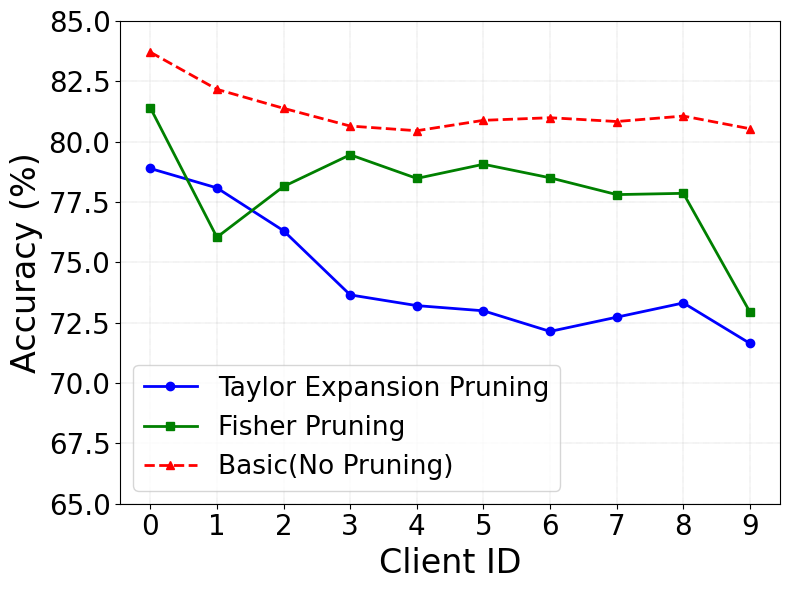

In [33]:
taylor = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-Taylor.npy')
basic = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-Basic.npy')
fisher = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-Fisher.npy')
taylor = [i-5 for i in taylor]

client_ids = list(range(10))

plt.figure(figsize=(8, 6))
plt.plot(client_ids, taylor, marker='o', label='Taylor Expansion Pruning', color='blue', linestyle='-', linewidth=2)
plt.plot(client_ids, fisher, marker='s', label='Fisher Pruning', color='green', linestyle='-', linewidth=2)
plt.plot(client_ids, basic, marker='^', label='Basic(No Pruning)', color='red', linestyle='--', linewidth=2)
plt.ylim(65, 85)
plt.xticks(client_ids,fontsize=20)  # Mark all client IDs
plt.yticks(fontsize=20)
plt.xlabel('Client ID',fontsize=24)
plt.ylabel('Accuracy (%)',fontsize=24)
# plt.title('Accuracy Comparison across Clients')
plt.legend(fontsize=19)

plt.grid(True, linestyle=':', linewidth=0.3, color='gray')
plt.tight_layout()
plt.show()

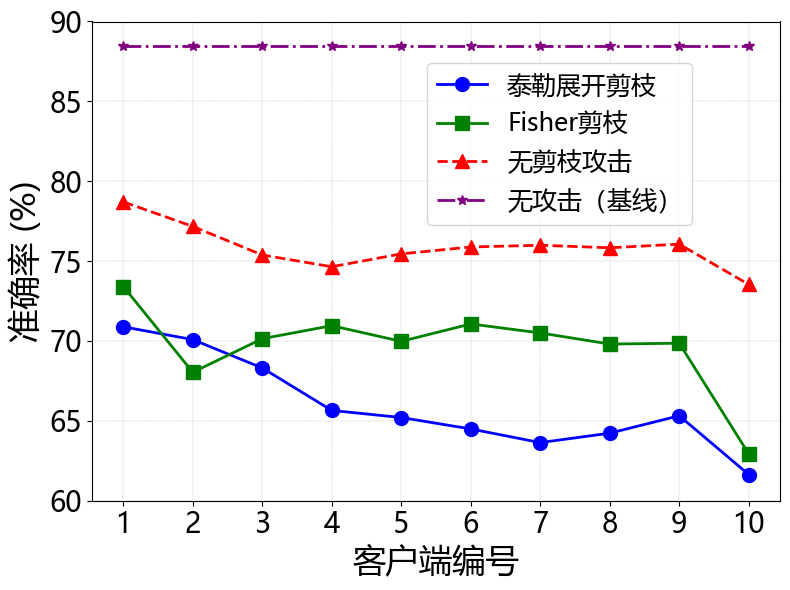

In [4]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
dataset = 'f_mnist'
att_type = 'unit'



taylor = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-Taylor.npy')
taylor = mtc(taylor, mode='taylor')
basic = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-Basic.npy')
basic = mtc(basic, mode='basic')
fisher = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-Fisher.npy')
fisher = mtc(fisher, mode='fisher')
client_ids = list(range(1,11))
baseline = [88.47] * 10

plt.figure(figsize=(8, 6))
plt.plot(client_ids, taylor, marker='o', markersize=10, label='泰勒展开剪枝', color='blue', linestyle='-', linewidth=2)
plt.plot(client_ids, fisher, marker='s', markersize=10, label='Fisher剪枝', color='green', linestyle='-', linewidth=2)
plt.plot(client_ids, basic, marker='^', markersize=10, label='无剪枝攻击', color='red', linestyle='--', linewidth=2)
plt.plot(client_ids, baseline, marker='*', markersize=7, label='无攻击（基线）', color='purple', linestyle='-.', linewidth=2)

plt.xticks(client_ids, fontsize=20)  # Mark all client IDs
plt.yticks(fontsize=20)
plt.xlabel('客户端编号', fontsize=24)
plt.ylabel('准确率 (%)', fontsize=24)
plt.ylim(60, 90)
plt.legend(fontsize=18)

legend = plt.legend(fontsize=18, loc='lower center', bbox_to_anchor=(0.68, 0.55))

plt.grid(True, linestyle=':', linewidth=0.3, color='gray')
plt.tight_layout()
plt.show()